<a href="https://colab.research.google.com/github/eltahir64-spec/Agentic-AI-memory-Implementation/blob/main/Security_Ops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas scikit-learn crewai SQLAlchemy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas
import sklearn
import crewai
import sqlalchemy
print("All required libraries (pandas, scikit-learn, crewai, sqlalchemy) imported successfully.")

All required libraries (pandas, scikit-learn, crewai, sqlalchemy) imported successfully.


In [ ]:
import sqlite3

# Connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect('security_events.db')
cursor = conn.cursor()

# Enable foreign key support
cursor.execute('PRAGMA foreign_keys = ON;')

# 1. Create 'users' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT UNIQUE NOT NULL,
    role TEXT NOT NULL
);
''')

# 2. Create 'authentication_logs' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS authentication_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    ip_address TEXT,
    status TEXT, -- e.g., 'success', 'failure'
    FOREIGN KEY (user_id) REFERENCES users(id)
);
''')

# 3. Create 'network_events' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS network_events (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    source_ip TEXT,
    destination_ip TEXT,
    protocol TEXT,
    port INTEGER,
    action TEXT, -- e.g., 'allow', 'deny'
    bytes_sent INTEGER,
    bytes_received INTEGER
);
''')

# 4. Create 'detected_incidents' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS detected_incidents (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_type TEXT NOT NULL,
    description TEXT,
    severity TEXT, -- e.g., 'low', 'medium', 'high', 'critical'
    detection_timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    status TEXT -- e.g., 'new', 'investigating', 'closed'
);
''')

# 5. Create 'response_actions' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS response_actions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_id INTEGER,
    action_taken TEXT NOT NULL,
    action_timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    performed_by TEXT,
    FOREIGN KEY (incident_id) REFERENCES detected_incidents(id)
);
''')

# Commit changes and close connection
conn.commit()
conn.close()

print("Database 'security_events.db' and tables created successfully.")


Database 'security_events.db' and tables created successfully.


In [ ]:
import sqlite3
import pandas as pd
from datetime import datetime, timedelta
import random
import ipaddress

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def insert_initial_users(conn, cursor):
    """Inserts initial users into the 'users' table and returns their IDs."""
    users_data = [
        ('admin', 'administrator'),
        ('user1', 'standard_user'),
        ('malicious_actor', 'external_threat'),
        ('analyst', 'security_analyst')
    ]
    inserted_user_ids = []
    for username, role in users_data:
        try:
            cursor.execute("INSERT INTO users (username, role) VALUES (?, ?)", (username, role))
            inserted_user_ids.append(cursor.lastrowid)
        except sqlite3.IntegrityError: # Handle unique constraint for username
            print(f"User '{username}' already exists. Skipping insertion.")
            cursor.execute("SELECT id FROM users WHERE username = ?", (username,))
            inserted_user_ids.append(cursor.fetchone()[0])
    conn.commit()
    print(f"Inserted/retrieved {len(inserted_user_ids)} users.")
    return inserted_user_ids

def generate_auth_logs(num_logs, user_ids):
    """Generates a list of dictionaries for authentication logs."""
    auth_logs = []
    start_time = datetime.now() - timedelta(days=30)
    for _ in range(num_logs):
        user_id = random.choice(user_ids)
        timestamp = start_time + timedelta(seconds=random.randint(0, 30*24*60*60))
        ip_address = str(ipaddress.IPv4Address(random.randint(0, 2**32 - 1)))
        status = random.choices(['success', 'failure'], weights=[0.8, 0.2], k=1)[0]
        auth_logs.append({
            'user_id': user_id,
            'timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'ip_address': ip_address,
            'status': status
        })
    return auth_logs

def generate_network_events(num_events):
    """Generates a list of dictionaries for network events."""
    network_events = []
    start_time = datetime.now() - timedelta(days=30)
    protocols = ['TCP', 'UDP', 'ICMP', 'HTTP', 'HTTPS']
    ports = [20, 21, 22, 23, 25, 53, 80, 110, 143, 443, 3389, 8080]
    actions = ['allow', 'deny', 'block']

    for _ in range(num_events):
        timestamp = start_time + timedelta(seconds=random.randint(0, 30*24*60*60))
        source_ip = str(ipaddress.IPv4Address(random.randint(0, 2**32 - 1)))
        destination_ip = str(ipaddress.IPv4Address(random.randint(0, 2**32 - 1)))
        protocol = random.choice(protocols)
        port = random.choice(ports)
        action = random.choices(actions, weights=[0.7, 0.2, 0.1], k=1)[0]
        bytes_sent = random.randint(100, 100000)
        bytes_received = random.randint(100, 100000)
        network_events.append({
            'timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'source_ip': source_ip,
            'destination_ip': destination_ip,
            'protocol': protocol,
            'port': port,
            'action': action,
            'bytes_sent': bytes_sent,
            'bytes_received': bytes_received
        })
    return network_events

def ingest_data(conn, cursor, table_name, data):
    """Ingests a list of dictionaries into the specified table."""
    if not data:
        print(f"No data to ingest for table {table_name}.")
        return

    columns = ', '.join(data[0].keys())
    placeholders = ', '.join('?' * len(data[0]))
    insert_sql = f"INSERT INTO {table_name} ({columns}) VALUES ({placeholders})"

    # Convert list of dictionaries to list of tuples for executemany
    values_to_insert = [tuple(d.values()) for d in data]

    cursor.executemany(insert_sql, values_to_insert)
    conn.commit()
    print(f"Ingested {len(data)} records into {table_name}.")

# Main execution
if __name__ == "__main__":
    conn, cursor = get_db_connection()

    # Insert initial users and get their IDs
    user_ids = insert_initial_users(conn, cursor)

    # Generate and ingest authentication logs
    num_auth_logs = 3000
    auth_logs = generate_auth_logs(num_auth_logs, user_ids)
    ingest_data(conn, cursor, 'authentication_logs', auth_logs)

    # Generate and ingest network events
    num_network_events = 5000
    network_events = generate_network_events(num_network_events)
    ingest_data(conn, cursor, 'network_events', network_events)

    # Verify record counts
    cursor.execute("SELECT COUNT(*) FROM users")
    print(f"Total users in 'users' table: {cursor.fetchone()[0]}")

    cursor.execute("SELECT COUNT(*) FROM authentication_logs")
    print(f"Total records in 'authentication_logs' table: {cursor.fetchone()[0]}")

    cursor.execute("SELECT COUNT(*) FROM network_events")
    print(f"Total records in 'network_events' table: {cursor.fetchone()[0]}")

    conn.close()


Inserted/retrieved 4 users.
Ingested 3000 records into authentication_logs.
Ingested 5000 records into network_events.
Total users in 'users' table: 4
Total records in 'authentication_logs' table: 3000
Total records in 'network_events' table: 5000


In [ ]:
import sqlite3
import pandas as pd
from datetime import datetime, timedelta

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    # Convert timestamp columns to datetime objects for easier manipulation
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    if 'detection_timestamp' in df.columns:
        df['detection_timestamp'] = pd.to_datetime(df['detection_timestamp'])
    return df

def ingest_incidents(conn, cursor, incidents):
    """Ingests a list of incident dictionaries into the detected_incidents table."""
    if not incidents:
        print("No incidents to ingest.")
        return

    # Define columns for detected_incidents table explicitly to match schema
    columns = ['incident_type', 'description', 'severity', 'detection_timestamp', 'status']
    placeholders = ', '.join('?' * len(columns))
    insert_sql = f"INSERT INTO detected_incidents ({', '.join(columns)}) VALUES ({placeholders})"

    values_to_insert = []
    for incident in incidents:
        # Ensure all required columns are present and in the correct order
        values_to_insert.append((
            incident.get('incident_type'),
            incident.get('description'),
            incident.get('severity'),
            incident.get('detection_timestamp', datetime.now().strftime('%Y-%m-%d %H:%M:%S')),
            incident.get('status')
        ))

    cursor.executemany(insert_sql, values_to_insert)
    conn.commit()
    print(f"Ingested {len(incidents)} records into detected_incidents.")

def detect_brute_force(auth_logs_df):
    """Detects brute-force attempts from authentication logs."""
    incidents = []
    failed_attempts = auth_logs_df[auth_logs_df['status'] == 'failure'].copy()

    if failed_attempts.empty:
        return incidents

    # Sort by user and timestamp to detect sequential failures
    failed_attempts = failed_attempts.sort_values(by=['user_id', 'ip_address', 'timestamp'])

    # Group by user_id and ip_address and apply a rolling window detection
    for (user_id, ip_address), group in failed_attempts.groupby(['user_id', 'ip_address']):
        if len(group) < 3: # Require at least 3 failed attempts to consider it a brute-force
            continue

        # Check for multiple failures within a 5-minute window
        group['time_diff'] = group['timestamp'].diff().dt.total_seconds()
        potential_brute_force = group[group['time_diff'] <= 300] # 5 minutes = 300 seconds

        if not potential_brute_force.empty:
            # Consolidate multiple closely-timed failures into one incident
            start_time = potential_brute_force['timestamp'].min()
            end_time = potential_brute_force['timestamp'].max()
            num_failures = len(potential_brute_force)
            description = (
                f"User {user_id} (from IP: {ip_address}) had {num_failures} failed login "
                f"attempts between {start_time.strftime('%Y-%m-%d %H:%M:%S')} and "
                f"{end_time.strftime('%Y-%m-%d %H:%M:%S')} (possible brute force)."
            )
            incidents.append({
                'incident_type': 'Brute Force Attack',
                'description': description,
                'severity': 'high',
                'detection_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'status': 'new'
            })
    return incidents

def detect_suspicious_network(network_events_df):
    """Detects suspicious network patterns (e.g., port scanning) from network events."""
    incidents = []
    denied_blocked_events = network_events_df[
        (network_events_df['action'] == 'deny') |
        (network_events_df['action'] == 'block')
    ].copy()

    if denied_blocked_events.empty:
        return incidents

    denied_blocked_events = denied_blocked_events.sort_values(by=['source_ip', 'timestamp'])

    # Group by source_ip and check for a high number of denied/blocked attempts
    # to different destinations/ports within a short period (e.g., 1 hour)
    time_window_seconds = 3600 # 1 hour
    min_unique_targets = 5    # Minimum unique destination IPs or ports
    min_events_in_window = 10 # Minimum denied/blocked events in the window

    for source_ip, group in denied_blocked_events.groupby('source_ip'):
        # Use a rolling window to check for bursts of activity
        group['timestamp_seconds'] = group['timestamp'].astype('int64') // 10**9 # Convert to Unix timestamp

        # Iterate through the sorted group to define windows
        for i in range(len(group)):
            current_event_time = group.iloc[i]['timestamp_seconds']
            window_start_time = current_event_time - time_window_seconds

            window_events = group[
                (group['timestamp_seconds'] >= window_start_time) &
                (group['timestamp_seconds'] <= current_event_time)
            ]

            if len(window_events) >= min_events_in_window:
                unique_destinations = window_events['destination_ip'].nunique()
                unique_ports = window_events['port'].nunique()

                if unique_destinations >= min_unique_targets or unique_ports >= min_unique_targets:
                    start_time = window_events['timestamp'].min()
                    end_time = window_events['timestamp'].max()
                    num_events = len(window_events)

                    # Check if this incident has already been reported to avoid duplicates
                    incident_description = (
                        f"Source IP {source_ip} showed {num_events} denied/blocked network events "
                        f"to {unique_destinations} unique destination IPs and {unique_ports} unique ports "
                        f"between {start_time.strftime('%Y-%m-%d %H:%M:%S')} and "
                        f"{end_time.strftime('%Y-%m-%d %H:%M:%S')} (possible port scan/unusual activity)."
                    )
                    # Simple deduplication: if an incident with this source_ip and similar description
                    # within a short time frame already exists, skip it.
                    is_duplicate = False
                    for existing_incident in incidents:
                        if (existing_incident['incident_type'] == 'Port Scan/Unusual Network Activity' and
                            existing_incident['description'].startswith(f"Source IP {source_ip}") and
                            abs((pd.to_datetime(existing_incident['detection_timestamp']) - start_time).total_seconds()) < time_window_seconds):
                            is_duplicate = True
                            break

                    if not is_duplicate:
                        incidents.append({
                            'incident_type': 'Port Scan/Unusual Network Activity',
                            'description': incident_description,
                            'severity': 'medium',
                            'detection_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                            'status': 'new'
                        })

    return incidents

# Main execution
if __name__ == "__main__":
    conn, cursor = get_db_connection()

    # Load data
    authentication_logs_df = load_data(conn, 'authentication_logs')
    network_events_df = load_data(conn, 'network_events')

    all_incidents = []

    # Detect brute-force attempts
    brute_force_incidents = detect_brute_force(authentication_logs_df)
    all_incidents.extend(brute_force_incidents)
    print(f"Detected {len(brute_force_incidents)} potential brute-force incidents.")

    # Detect suspicious network patterns
    suspicious_network_incidents = detect_suspicious_network(network_events_df)
    all_incidents.extend(suspicious_network_incidents)
    print(f"Detected {len(suspicious_network_incidents)} suspicious network incidents.")

    # Ingest all detected incidents
    ingest_incidents(conn, cursor, all_incidents)

    # Verify record counts
    cursor.execute("SELECT COUNT(*) FROM detected_incidents")
    print(f"Total records in 'detected_incidents' table: {cursor.fetchone()[0]}")

    conn.close()

Detected 0 potential brute-force incidents.
Detected 0 suspicious network incidents.
No incidents to ingest.
Total records in 'detected_incidents' table: 0


In [ ]:
import sqlite3
import pandas as pd

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

conn, cursor = get_db_connection()

authentication_logs_df = load_data(conn, 'authentication_logs')
network_events_df = load_data(conn, 'network_events')

print("\n--- Authentication Logs Analysis ---")
failed_auth_attempts = authentication_logs_df[authentication_logs_df['status'] == 'failure']
print(f"Total failed authentication attempts: {len(failed_auth_attempts)}")
if not failed_auth_attempts.empty:
    print("Top IPs with failed attempts:")
    print(failed_auth_attempts['ip_address'].value_counts().head())
    print("Top Users with failed attempts:")
    print(failed_auth_attempts['user_id'].value_counts().head())

print("\n--- Network Events Analysis ---")
denied_blocked_events = network_events_df[
    (network_events_df['action'] == 'deny') |
    (network_events_df['action'] == 'block')
]
print(f"Total denied/blocked network events: {len(denied_blocked_events)}")
if not denied_blocked_events.empty:
    print("Top Source IPs with denied/blocked events:")
    print(denied_blocked_events['source_ip'].value_counts().head())

conn.close()



--- Authentication Logs Analysis ---
Total failed authentication attempts: 590
Top IPs with failed attempts:
ip_address
115.14.31.203      1
30.212.110.158     1
38.247.132.20      1
127.220.149.162    1
49.203.70.42       1
Name: count, dtype: int64
Top Users with failed attempts:
user_id
2    160
3    152
4    152
1    126
Name: count, dtype: int64

--- Network Events Analysis ---
Total denied/blocked network events: 1496
Top Source IPs with denied/blocked events:
source_ip
123.111.36.238    1
221.68.217.196    1
242.0.110.119     1
186.26.92.49      1
9.60.212.120      1
Name: count, dtype: int64


In [ ]:
from crewai import Agent, Task

print("CrewAI components (Agent, Task) imported successfully.")
print("Utility functions (get_db_connection, load_data, ingest_incidents, detect_brute_force, detect_suspicious_network) are assumed to be available from previous cell executions.")

CrewAI components (Agent, Task) imported successfully.
Utility functions (get_db_connection, load_data, ingest_incidents, detect_brute_force, detect_suspicious_network) are assumed to be available from previous cell executions.


In [ ]:
import os
from crewai import Agent

# Set dummy API key and model name to bypass validation during agent definition
# A real API key would be required for actual LLM interactions.
os.environ['OPENAI_API_KEY'] = 'sk-dummykey'
os.environ['OPENAI_MODEL_NAME'] = 'gpt-4o-mini'

ThreatDetectionAgent = Agent(
    role='Cybersecurity Threat Detector',
    goal='Identify and classify cybersecurity threats from authentication logs and network events',
    backstory='You are an AI-driven cybersecurity expert specializing in detecting and classifying threats based on log analysis and network traffic patterns.',
    verbose=True,
    allow_delegation=False
)

print("ThreatDetectionAgent defined successfully.")
print("Note: A dummy API key was set to allow agent definition. For actual LLM interactions, provide a valid API key.")

ThreatDetectionAgent defined successfully.
Note: A dummy API key was set to allow agent definition. For actual LLM interactions, provide a valid API key.


In [ ]:
brute_force_detection_task = Task(
    agent=ThreatDetectionAgent,
    description=(
        "Analyze the `authentication_logs_df` for patterns indicative of brute-force attacks. "
        "Specifically, look for multiple failed login attempts from the same user_id and ip_address "
        "within a short time window (e.g., 5 minutes)."
    ),
    expected_output=(
        "A list of dictionaries, where each dictionary represents a detected brute-force incident. "
        "Each incident dictionary must include 'incident_type' (e.g., 'Brute Force Attack'), "
        "'description' detailing the specifics, 'severity' (e.g., 'high'), 'detection_timestamp' in "
        "'YYYY-MM-DD HH:MM:SS' format, and 'status' (e.g., 'new')."
    ),
    action=lambda: detect_brute_force(authentication_logs_df)
)

print("Brute-force detection task created successfully.")

Brute-force detection task created successfully.


In [ ]:
suspicious_network_detection_task = Task(
    agent=ThreatDetectionAgent,
    description=(
        "Analyze the `network_events_df` for patterns indicative of suspicious network activity, "
        "such as port scanning or unusual connection attempts. "
        "Specifically, look for a high number of denied or blocked connection attempts from the "
        "same source_ip to different destination IPs or ports within a short period (e.g., 1 hour)."
    ),
    expected_output=(
        "A list of dictionaries, where each dictionary represents a detected suspicious network incident. "
        "Each incident dictionary must include 'incident_type' (e.g., 'Port Scan', 'Unusual Network Activity'), "
        "'description' detailing the specifics, 'severity' (e.g., 'medium' or 'high'), 'detection_timestamp' in "
        "'YYYY-MM-DD HH:MM:SS' format, and 'status' (e.g., 'new')."
    ),
    action=lambda: detect_suspicious_network(network_events_df)
)

print("Suspicious network detection task created successfully.")

Suspicious network detection task created successfully.


In [ ]:
import sqlite3
import pandas as pd

# Reuse get_db_connection and load_data functions from previous cells
def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    # Convert timestamp columns to datetime objects for easier manipulation
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    if 'detection_timestamp' in df.columns:
        df['detection_timestamp'] = pd.to_datetime(df['detection_timestamp'])
    return df


# 1. Establish connection to the database
conn, cursor = get_db_connection()
print("Database connection established.")

# 2. Load authentication_logs table into authentication_logs_df
authentication_logs_df = load_data(conn, 'authentication_logs')
print("authentication_logs table loaded.")

# 3. Load network_events table into network_events_df
network_events_df = load_data(conn, 'network_events')
print("network_events table loaded.")

# 4. Close the database connection
conn.close()
print("Database connection closed.")

# 5. Print the first few rows and display info for both DataFrames
print("\n--- authentication_logs_df Head ---")
print(authentication_logs_df.head())
print("\n--- authentication_logs_df Info ---")
authentication_logs_df.info()

print("\n--- network_events_df Head ---")
print(network_events_df.head())
print("\n--- network_events_df Info ---")
network_events_df.info()

Database connection established.
authentication_logs table loaded.
network_events table loaded.
Database connection closed.

--- authentication_logs_df Head ---
   id  user_id           timestamp      ip_address   status
0   1        2 2026-04-02 09:44:04    10.183.42.34  success
1   2        4 2026-04-04 18:45:22   62.56.112.241  success
2   3        3 2026-04-17 03:01:42  25.246.213.211  success
3   4        3 2026-03-30 08:24:19  195.43.168.222  success
4   5        1 2026-03-31 12:39:50   37.37.196.243  success

--- authentication_logs_df Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          3000 non-null   int64         
 1   user_id     3000 non-null   int64         
 2   timestamp   3000 non-null   datetime64[ns]
 3   ip_address  3000 non-null   object        
 4   status      3000 non-null   object        


In [ ]:
print("\n--- Missing values in network_events_df ---")
print(network_events_df.isnull().sum())


--- Missing values in network_events_df ---
id                0
timestamp         0
source_ip         0
destination_ip    0
protocol          0
port              0
action            0
bytes_sent        0
bytes_received    0
dtype: int64


In [ ]:
print("\n--- network_events_df Head (First 10 Rows) ---")
print(network_events_df.head(10))


--- network_events_df Head (First 10 Rows) ---
   id           timestamp        source_ip   destination_ip protocol  port  \
0   1 2026-04-18 13:58:12    110.122.94.72   224.171.96.210      UDP  3389   
1   2 2026-04-08 07:32:08    212.217.52.13    192.71.83.134    HTTPS   443   
2   3 2026-04-11 08:10:30   35.216.179.126   199.64.254.194     ICMP   110   
3   4 2026-03-23 18:04:42     188.36.28.66   101.248.152.11      UDP   443   
4   5 2026-04-03 10:10:35   221.68.217.196   156.222.22.204      UDP    80   
5   6 2026-04-12 02:35:37   21.169.191.229  121.128.194.195      UDP    25   
6   7 2026-03-30 23:57:16    242.0.110.119    40.179.156.93     ICMP   143   
7   8 2026-03-25 13:16:42     37.229.29.40   211.127.181.15     ICMP    22   
8   9 2026-03-21 23:44:47     98.4.193.129    234.149.90.59     HTTP    20   
9  10 2026-04-03 04:10:15  125.166.187.148      39.8.61.202    HTTPS   443   

  action  bytes_sent  bytes_received  
0  allow        2284           28551  
1  allow       

In [ ]:
print("\n--- Summary Statistics for network_events_df ---")
print(network_events_df.describe())


--- Summary Statistics for network_events_df ---
                id                      timestamp         port    bytes_sent  \
count  5000.000000                           5000  5000.000000   5000.000000   
mean   2500.500000  2026-04-04 08:39:49.038800128  1043.291200  50932.402600   
min       1.000000            2026-03-20 10:57:28    20.000000    106.000000   
25%    1250.750000            2026-03-27 17:45:06    23.000000  25464.250000   
50%    2500.500000     2026-04-04 08:49:55.500000    80.000000  51900.500000   
75%    3750.250000            2026-04-11 20:41:38   143.000000  76116.500000   
max    5000.000000            2026-04-19 10:34:05  8080.000000  99959.000000   
std    1443.520003                            NaN  2338.329843  28940.305108   

       bytes_received  
count     5000.000000  
mean     50579.334000  
min        109.000000  
25%      26732.500000  
50%      50466.500000  
75%      75782.500000  
max      99979.000000  
std      28510.968941  


In [ ]:
blocked_events_df = network_events_df[network_events_df['action'] == 'block']

print(f"Original network_events_df shape: {network_events_df.shape}")
print(f"Blocked events detected: {blocked_events_df.shape[0]}")
print("First 5 rows of blocked_events_df:")
print(blocked_events_df.head())

Original network_events_df shape: (5000, 9)
Blocked events detected: 491
First 5 rows of blocked_events_df:
    id           timestamp       source_ip   destination_ip protocol  port  \
19  20 2026-04-12 06:54:06  196.183.227.11     4.153.88.163     ICMP    53   
24  25 2026-03-31 20:14:12  173.229.81.241    83.183.45.121      TCP   110   
26  27 2026-03-25 05:20:22  219.206.204.97  138.249.177.126    HTTPS   443   
43  44 2026-04-11 13:09:04   34.173.205.99    170.142.193.8      TCP    22   
47  48 2026-03-23 23:02:37   60.83.207.241    85.84.240.181      UDP    23   

   action  bytes_sent  bytes_received  
19  block       94919           73913  
24  block       97197            6160  
26  block       87790           71489  
43  block       70299           47907  
47  block       17863           67280  


In [ ]:
total_failed_attempts = len(failed_auth_attempts)
top_failed_ips = failed_auth_attempts['ip_address'].value_counts().head(5)
top_failed_users = failed_auth_attempts['user_id'].value_counts().head(5)

print(f"Total failed authentication attempts: {total_failed_attempts}")
print("\nTop 5 IPs with failed attempts:")
print(top_failed_ips)
print("\nTop 5 Users with failed attempts:")
print(top_failed_users)

Total failed authentication attempts: 590

Top 5 IPs with failed attempts:
ip_address
115.14.31.203      1
30.212.110.158     1
38.247.132.20      1
127.220.149.162    1
49.203.70.42       1
Name: count, dtype: int64

Top 5 Users with failed attempts:
user_id
2    160
3    152
4    152
1    126
Name: count, dtype: int64


In [ ]:
total_denied_blocked_events = len(denied_blocked_events)
top_denied_blocked_ips = denied_blocked_events['source_ip'].value_counts().head(5)

print(f"Total denied/blocked network events: {total_denied_blocked_events}")
print("\nTop 5 Source IPs with denied/blocked events:")
print(top_denied_blocked_ips)

Total denied/blocked network events: 1496

Top 5 Source IPs with denied/blocked events:
source_ip
123.111.36.238    1
221.68.217.196    1
242.0.110.119     1
186.26.92.49      1
9.60.212.120      1
Name: count, dtype: int64


**Reasoning**:
To fulfill the subtask, I will filter the `network_events_df` based on the 'action' column to create `denied_blocked_events_df` and display its shape and head.



In [ ]:
denied_blocked_events_df = network_events_df[
    (network_events_df['action'] == 'deny') |
    (network_events_df['action'] == 'block')
]

print(f"Shape of network_events_df: {network_events_df.shape}")
print(f"Shape of denied_blocked_events_df: {denied_blocked_events_df.shape}")
print("First 5 rows of denied_blocked_events_df:")
print(denied_blocked_events_df.head())

Shape of network_events_df: (5000, 9)
Shape of denied_blocked_events_df: (1496, 9)
First 5 rows of denied_blocked_events_df:
    id           timestamp       source_ip  destination_ip protocol  port  \
4    5 2026-04-03 10:10:35  221.68.217.196  156.222.22.204      UDP    80   
6    7 2026-03-30 23:57:16   242.0.110.119   40.179.156.93     ICMP   143   
11  12 2026-04-17 23:05:59    186.26.92.49    52.28.249.60     HTTP    21   
17  18 2026-03-31 15:05:18    9.60.212.120  169.239.223.88      TCP  8080   
19  20 2026-04-12 06:54:06  196.183.227.11    4.153.88.163     ICMP    53   

   action  bytes_sent  bytes_received  
4    deny       67277           74745  
6    deny       52660           85337  
11   deny        9824            6310  
17   deny       72876           19382  
19  block       94919           73913  


In [ ]:
html_dashboard_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Security Events Dashboard</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; color: #333; }}
        .container {{ background-color: #fff; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); max-width: 800px; margin: auto; }}
        h1 {{ color: #0056b3; text-align: center; margin-bottom: 30px; }}
        h2 {{ color: #007bff; border-bottom: 2px solid #eee; padding-bottom: 10px; margin-top: 30px; }}
        p {{ line-height: 1.6; }}
        .statistic {{ background-color: #e9f5ff; border-left: 5px solid #007bff; padding: 10px; margin-bottom: 10px; border-radius: 4px; }}
        .statistic strong {{ color: #0056b3; }}
        ul {{ list-style-type: none; padding: 0; }}
        li {{ background-color: #f0f8ff; margin-bottom: 5px; padding: 8px; border-radius: 4px; border: 1px solid #e1f0ff; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>Security Events Dashboard</h1>

        <h2>Authentication Log Insights</h2>
        <div class="statistic">
            <strong>Total Failed Authentication Attempts:</strong> {total_failed_attempts}
        </div>
        <h3>Top 5 IPs with Failed Attempts:</h3>
        <ul>
"""
for ip, count in top_failed_ips.items():
    html_dashboard_content += f"            <li>{ip}: {count} attempts</li>\n"
html_dashboard_content += f"""
        </ul>
        <h3>Top 5 Users with Failed Attempts:</h3>
        <ul>
"""
for user, count in top_failed_users.items():
    html_dashboard_content += f"            <li>User ID {user}: {count} attempts</li>\n"
html_dashboard_content += f"""
        </ul>

        <h2>Network Event Insights</h2>
        <div class="statistic">
            <strong>Total Denied/Blocked Network Events:</strong> {total_denied_blocked_events}
        </div>
        <h3>Top 5 Source IPs with Denied/Blocked Events:</h3>
        <ul>
"""
for ip, count in top_denied_blocked_ips.items():
    html_dashboard_content += f"            <li>{ip}: {count} events</li>\n"
html_dashboard_content += f"""
        </ul>
    </div>
</body>
</html>
"""

# Display the HTML content (this will render as HTML in a Jupyter/Colab environment)
from IPython.display import HTML
HTML(html_dashboard_content)

print("HTML dashboard content generated and displayed.")


HTML dashboard content generated and displayed.


In [ ]:
denied_actions_by_protocol = denied_blocked_events_df['protocol'].value_counts()

print("Denied/Blocked Network Events by Protocol:")
print(denied_actions_by_protocol)

Denied/Blocked Network Events by Protocol:
protocol
HTTP     317
UDP      302
HTTPS    302
ICMP     288
TCP      287
Name: count, dtype: int64


/tmp/ipykernel_15115/2685746801.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=denied_actions_by_protocol.index, y=denied_actions_by_protocol.values, palette='viridis')


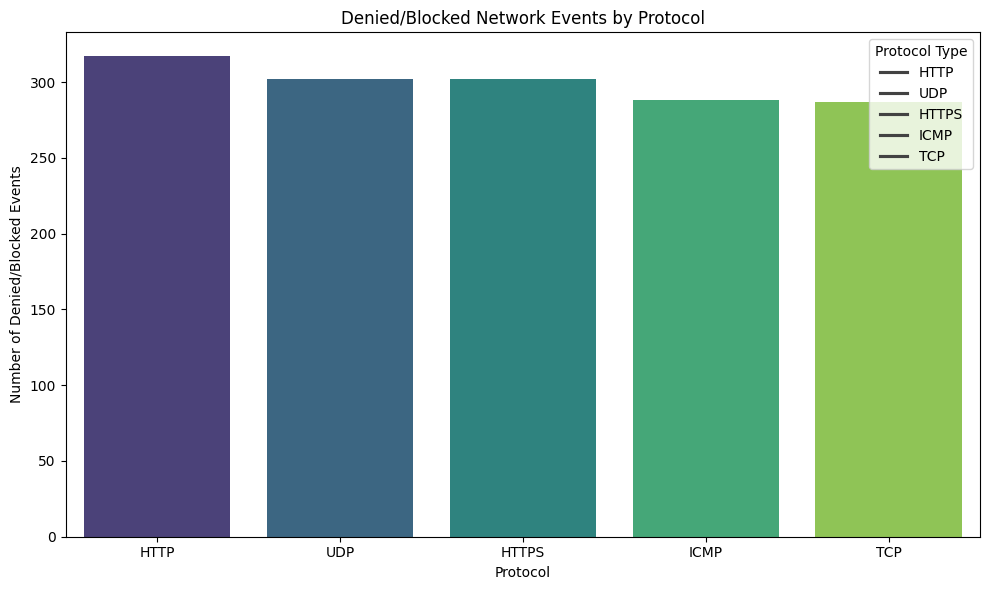

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=denied_actions_by_protocol.index, y=denied_actions_by_protocol.values, palette='viridis')

# Label the x-axis
plt.xlabel('Protocol')
# Label the y-axis
plt.ylabel('Number of Denied/Blocked Events')
# Set the title of the chart
plt.title('Denied/Blocked Network Events by Protocol')
# Add a legend (optional for a single series bar chart, but good practice if more categories were involved)
plt.legend(title='Protocol Type', labels=denied_actions_by_protocol.index)
# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
!pip install streamlit
print("Streamlit installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 26.0 MB/s eta 0:00:00
Streamlit installed successfully.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    # Convert timestamp columns to datetime objects for easier manipulation
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    if 'detection_timestamp' in df.columns:
        df['detection_timestamp'] = pd.to_datetime(df['detection_timestamp'])
    return df

# 1. Database connection and data loading
conn, cursor = get_db_connection()
authentication_logs_df = load_data(conn, 'authentication_logs')
network_events_df = load_data(conn, 'network_events')
conn.close()

# 2. Streamlit App Title
st.title('Security Events Dashboard')

st.write("### Data Loaded Successfully")
st.write("Authentication Logs:", authentication_logs_df.head())
st.write("Network Events:", network_events_df.head())

Writing app.py


In [ ]:
%%writefile -a app.py

# Authentication Log Analysis
failed_auth_attempts = authentication_logs_df[authentication_logs_df['status'] == 'failure']
total_failed_attempts = len(failed_auth_attempts)
top_failed_ips = failed_auth_attempts['ip_address'].value_counts().head(5)
top_failed_users = failed_auth_attempts['user_id'].value_counts().head(5)

st.header('Authentication Log Insights')
st.metric('Total Failed Authentication Attempts', total_failed_attempts)

with st.expander('Top 5 IPs with Failed Attempts'):
    st.table(top_failed_ips)

with st.expander('Top 5 Users with Failed Attempts'):
    st.table(top_failed_users)


Appending to app.py


In [ ]:
%%writefile -a app.py

# Network Event Analysis
denied_blocked_events_df = network_events_df[
    (network_events_df['action'] == 'deny') |
    (network_events_df['action'] == 'block')
]
total_denied_blocked_events = len(denied_blocked_events_df)
top_denied_blocked_ips = denied_blocked_events_df['source_ip'].value_counts().head(5)
denied_actions_by_protocol = denied_blocked_events_df['protocol'].value_counts()

st.header('Network Event Insights')
st.metric('Total Denied/Blocked Network Events', total_denied_blocked_events)

with st.expander('Top 5 Source IPs with Denied/Blocked Events'):
    st.table(top_denied_blocked_ips)

st.write('Denied/Blocked Network Events by Protocol:')
st.write(denied_actions_by_protocol)

# Bar chart for denied/blocked events by protocol
plt.figure(figsize=(10, 6))
sns.barplot(x=denied_actions_by_protocol.index, y=denied_actions_by_protocol.values, palette='viridis')
plt.xlabel('Protocol')
plt.ylabel('Number of Denied/Blocked Events')
plt.title('Denied/Blocked Network Events by Protocol')
plt.tight_layout()
st.pyplot(plt)
plt.clf() # Clear the current figure to prevent overlapping plots

Appending to app.py


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    # Convert timestamp columns to datetime objects for easier manipulation
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    if 'detection_timestamp' in df.columns:
        df['detection_timestamp'] = pd.to_datetime(df['detection_timestamp'])
    return df

# 1. Database connection and data loading
conn, cursor = get_db_connection()
authentication_logs_df = load_data(conn, 'authentication_logs')
network_events_df = load_data(conn, 'network_events')
conn.close()

# 2. Streamlit App Title
st.title('Security Events Dashboard')

# Create a sidebar for navigation
st.sidebar.header("Navigation")
selected_section = st.sidebar.radio("Go to", ["Authentication Log Insights", "Network Event Insights"])

# 3. Implement conditional rendering based on selected_section
if selected_section == "Authentication Log Insights":
    st.header('Authentication Log Insights')

    # Create tabs for Authentication Log Insights
    auth_tab1, auth_tab2 = st.tabs(["Overview", "Details"])

    with auth_tab1:
        # Authentication Log Analysis - Overview
        failed_auth_attempts = authentication_logs_df[authentication_logs_df['status'] == 'failure']
        total_failed_attempts = len(failed_auth_attempts)
        st.metric('Total Failed Authentication Attempts', total_failed_attempts)

    with auth_tab2:
        # Authentication Log Analysis - Details
        failed_auth_attempts = authentication_logs_df[authentication_logs_df['status'] == 'failure'] # Recalculate if not global
        top_failed_ips = failed_auth_attempts['ip_address'].value_counts().head(5)
        top_failed_users = failed_auth_attempts['user_id'].value_counts().head(5)

        st.subheader('Top 5 IPs with Failed Attempts:')
        st.table(top_failed_ips)

        st.subheader('Top 5 Users with Failed Attempts:')
        st.table(top_failed_users)

elif selected_section == "Network Event Insights":
    st.header('Network Event Insights')

    # Create tabs for Network Event Insights
    net_tab1, net_tab2 = st.tabs(["Overview", "Protocols"])

    with net_tab1:
        # Network Event Analysis - Overview
        denied_blocked_events_df = network_events_df[
            (network_events_df['action'] == 'deny') |
            (network_events_df['action'] == 'block')
        ]
        total_denied_blocked_events = len(denied_blocked_events_df)
        top_denied_blocked_ips = denied_blocked_events_df['source_ip'].value_counts().head(5)

        st.metric('Total Denied/Blocked Network Events', total_denied_blocked_events)

        st.subheader('Top 5 Source IPs with Denied/Blocked Events:')
        st.table(top_denied_blocked_ips)

    with net_tab2:
        # Network Event Analysis - Protocols
        denied_blocked_events_df = network_events_df[
            (network_events_df['action'] == 'deny') |
            (network_events_df['action'] == 'block')
        ] # Recalculate if not global
        denied_actions_by_protocol = denied_blocked_events_df['protocol'].value_counts()

        st.subheader('Denied/Blocked Network Events by Protocol:')
        st.write(denied_actions_by_protocol)

        # Bar chart for denied/blocked events by protocol
        plt.figure(figsize=(10, 6))
        sns.barplot(x=denied_actions_by_protocol.index, y=denied_actions_by_protocol.values, palette='viridis')
        plt.xlabel('Protocol')
        plt.ylabel('Number of Denied/Blocked Events')
        plt.title('Denied/Blocked Network Events by Protocol')
        plt.tight_layout()
        st.pyplot(plt)
        plt.clf() # Clear the current figure to prevent overlapping plots


Overwriting app.py


In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.80.122.156:8501



In [ ]:
pip install streamlit-i18n

Next, let's create a `languages.toml` file to define our translations. I'll include English and French examples for the main title and some key sections of your dashboard.

In [ ]:
%%writefile languages.toml
[languages]
names = ["English", "Français"]
keys = ["en", "fr"]
default_lang = "en"

[translations]

[translations.en]
app_title = "Security Events Dashboard"
auth_log_insights = "Authentication Log Insights"
auth_overview = "Overview"
auth_details = "Details"
total_failed_auth_attempts = "Total Failed Authentication Attempts"
top_ips_failed_attempts = "Top 5 IPs with Failed Attempts"
top_users_failed_attempts = "Top 5 Users with Failed Attempts"
network_event_insights = "Network Event Insights"
net_overview = "Overview"
net_protocols = "Protocols"
total_denied_blocked_events = "Total Denied/Blocked Network Events"
top_source_ips_denied_blocked = "Top 5 Source IPs with Denied/Blocked Events"
denied_blocked_events_by_protocol = "Denied/Blocked Network Events by Protocol"
protocol = "Protocol"
number_of_denied_blocked_events = "Number of Denied/Blocked Events"

[translations.fr]
app_title = "Tableau de bord des événements de sécurité"
auth_log_insights = "Aperçus des journaux d'authentification"
auth_overview = "Aperçu"
auth_details = "Détails"
total_failed_auth_attempts = "Total des tentatives d'authentification échouées"
top_ips_failed_attempts = "Top 5 des adresses IP avec tentatives échouées"
top_users_failed_attempts = "Top 5 des utilisateurs avec tentatives échouées"
network_event_insights = "Aperçus des événements réseau"
net_overview = "Aperçu"
net_protocols = "Protocoles"
total_denied_blocked_events = "Total des événements réseau refusés/bloqués"
top_source_ips_denied_blocked = "Top 5 des adresses IP source avec événements refusés/bloqués"
denied_blocked_events_by_protocol = "Événements réseau refusés/bloqués par protocole"
protocol = "Protocole"
number_of_denied_blocked_events = "Nombre d'événements refusés/bloqués"

Now, I'll modify the `app.py` file to incorporate the `streamlit-i18n` library. This will allow users to select their preferred language, and the dashboard elements will be displayed in that language. I'll replace the hardcoded strings with calls to the translation function `i18n.t()`.

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from streamlit_i18n import StreamlitI18n, toml_config

# Load i18n configuration from languages.toml
i18n_config = toml_config("languages.toml")
i18n = StreamlitI18n(i18n_config)
i18n.set_lang_from_query_params()

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    # Convert timestamp columns to datetime objects for easier manipulation
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    if 'detection_timestamp' in df.columns:
        df['detection_timestamp'] = pd.to_datetime(df['detection_timestamp'])
    return df

# 1. Database connection and data loading
conn, cursor = get_db_connection()
authentication_logs_df = load_data(conn, 'authentication_logs')
network_events_df = load_data(conn, 'network_events')
conn.close()

# 2. Streamlit App Title
st.title(i18n.t("app_title"))

# Add language selector to the sidebar
st.sidebar.header("Language")
i18n.select_lang_sidebar()

# Create a sidebar for navigation
st.sidebar.header("Navigation")
selected_section = st.sidebar.radio(
    "Go to",
    [i18n.t("auth_log_insights"), i18n.t("network_event_insights")]
)

# 3. Implement conditional rendering based on selected_section
if selected_section == i18n.t("auth_log_insights"):
    st.header(i18n.t("auth_log_insights"))

    # Create tabs for Authentication Log Insights
    auth_tab1, auth_tab2 = st.tabs([i18n.t("auth_overview"), i18n.t("auth_details")])

    with auth_tab1:
        # Authentication Log Analysis - Overview
        failed_auth_attempts = authentication_logs_df[authentication_logs_df['status'] == 'failure']
        total_failed_attempts = len(failed_auth_attempts)
        st.metric(i18n.t("total_failed_auth_attempts"), total_failed_attempts)

    with auth_tab2:
        # Authentication Log Analysis - Details
        failed_auth_attempts = authentication_logs_df[authentication_logs_df['status'] == 'failure'] # Recalculate if not global
        top_failed_ips = failed_auth_attempts['ip_address'].value_counts().head(5)
        top_failed_users = failed_auth_attempts['user_id'].value_counts().head(5)

        st.subheader(i18n.t("top_ips_failed_attempts"))
        st.table(top_failed_ips)

        st.subheader(i18n.t("top_users_failed_attempts"))
        st.table(top_failed_users)

elif selected_section == i18n.t("network_event_insights"):
    st.header(i18n.t("network_event_insights"))

    # Create tabs for Network Event Insights
    net_tab1, net_tab2 = st.tabs([i18n.t("net_overview"), i18n.t("net_protocols")])

    with net_tab1:
        # Network Event Analysis - Overview
        denied_blocked_events_df = network_events_df[
            (network_events_df['action'] == 'deny') |
            (network_events_df['action'] == 'block')
        ]
        total_denied_blocked_events = len(denied_blocked_events_df)
        top_denied_blocked_ips = denied_blocked_events_df['source_ip'].value_counts().head(5)

        st.metric(i18n.t("total_denied_blocked_events"), total_denied_blocked_events)

        st.subheader(i18n.t("top_source_ips_denied_blocked"))
        st.table(top_denied_blocked_ips)

    with net_tab2:
        # Network Event Analysis - Protocols
        denied_blocked_events_df = network_events_df[
            (network_events_df['action'] == 'deny') |
            (network_events_df['action'] == 'block')
        ] # Recalculate if not global
        denied_actions_by_protocol = denied_blocked_events_df['protocol'].value_counts()

        st.subheader(i18n.t("denied_blocked_events_by_protocol"))
        st.write(denied_actions_by_protocol)

        # Bar chart for denied/blocked events by protocol
        plt.figure(figsize=(10, 6))
        sns.barplot(x=denied_actions_by_protocol.index, y=denied_actions_by_protocol.values, palette='viridis')
        plt.xlabel(i18n.t("protocol"))
        plt.ylabel(i18n.t("number_of_denied_blocked_events"))
        plt.title(i18n.t("denied_blocked_events_by_protocol"))
        plt.tight_layout()
        st.pyplot(plt)
        plt.clf()

Now, run the Streamlit app again to see the multi-language support in action. You should see a language selector in the sidebar.

In [ ]:
!streamlit run app.py